In [1]:
import os
import time
import random
import warnings
from datetime import date

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects
from ydata_profiling import ProfileReport
import geopandas as gpd
from sklearn.metrics import ConfusionMatrixDisplay


current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *
from clean import *
from visualisation_utils import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
# os.chdir(r'C:\Users\adamp\Projects\CVUT_BAP')
SEED=42
PRINT = True

# Nacteni prepocitanych metrik

In [2]:
# Načtení dat z exportovaného JSON souboru
with open('kod/modelovani/feature_importance_analysis.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Příprava dat pro konfuzní matici
# Převedení seznamu na NumPy pole pro scikit-learn display
cm_values = np.array(data['confusion_matrix']['values'])
cm_labels = data['confusion_matrix']['labels']

# Příprava a seřazení dat pro Feature Importance (LossFunctionChange)
fi_test_raw = data['feature_importance']
fi_test_sorted = sorted(fi_test_raw, key=lambda x: x['test_importance_loss_change'], reverse=True)

test_labels = [item['feature'] for item in fi_test_sorted]
test_values = [item['test_importance_loss_change'] for item in fi_test_sorted]

# Metriky odvozene z konfuzni matice

----------------------------------------
METRIKY KONFUZNÍ MATICE
----------------------------------------
F1 Skóre:            0.1535
Recall (1):          0.2576
Precision (1):       0.1094
Accuracy:            0.9249
----------------------------------------
RELATIVNÍ ROZDĚLENÍ (v %):
Úspěch (0)      |  91.80% (TN) |   5.55% (FP)
Neúspěch (1)    |   1.96% (FN) |   0.68% (TP)
----------------------------------------
ABSOLUTNÍ HODNOTY:
Úspěch (0)      |          0 (TN) |          0 (FP)
Neúspěch (1)    |          0 (FN) |          0 (TP)
----------------------------------------


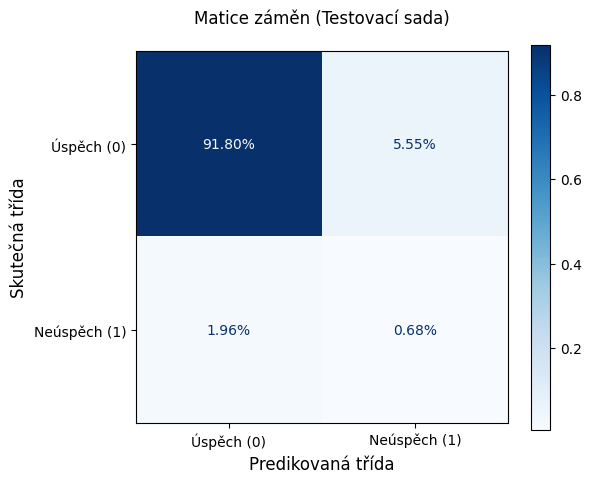

In [3]:
fig_cm, ax_cm = plt.subplots(figsize=(6, 5), facecolor='white')
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_values/np.sum(cm_values), 
    display_labels=cm_labels
)
disp.plot(cmap='Blues', ax=ax_cm, values_format='.2%')
ax_cm.set_title('Matice záměn (Testovací sada)', pad=20)
ax_cm.set_xlabel('Predikovaná třída', fontsize=12)
ax_cm.set_ylabel('Skutečná třída', fontsize=12)
fig_cm.savefig('kod/modelovani/matice_zamen.svg', format='svg', bbox_inches='tight')

tn, fp = cm_values[0]
fn, tp = cm_values[1]
total = np.sum(cm_values)

# Výpočty metrik
accuracy = (tp + tn) / total
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Výpočet procentuálního zastoupení v matici (Relativní matice)
cm_rel = (cm_values / total) * 100

print("-" * 40)
print(f"METRIKY KONFUZNÍ MATICE")
print("-" * 40)
print(f"{'F1 Skóre:':<20} {f1_score:.4f}")
print(f"{'Recall (1):':<20} {recall:.4f}")
print(f"{'Precision (1):':<20} {precision:.4f}")
print(f"{'Accuracy:':<20} {accuracy:.4f}")
print("-" * 40)
print("RELATIVNÍ ROZDĚLENÍ (v %):")
print(f"{cm_labels[0]:<15} | {cm_rel[0][0]:6.2f}% (TN) | {cm_rel[0][1]:6.2f}% (FP)")
print(f"{cm_labels[1]:<15} | {cm_rel[1][0]:6.2f}% (FN) | {cm_rel[1][1]:6.2f}% (TP)")
print("-" * 40)
print("ABSOLUTNÍ HODNOTY:")
print(f"{cm_labels[0]:<15} | {int(tn):>10} (TN) | {int(fp):>10} (FP)")
print(f"{cm_labels[1]:<15} | {int(fn):>10} (FN) | {int(tp):>10} (TP)")
print("-" * 40)

# Feature importance

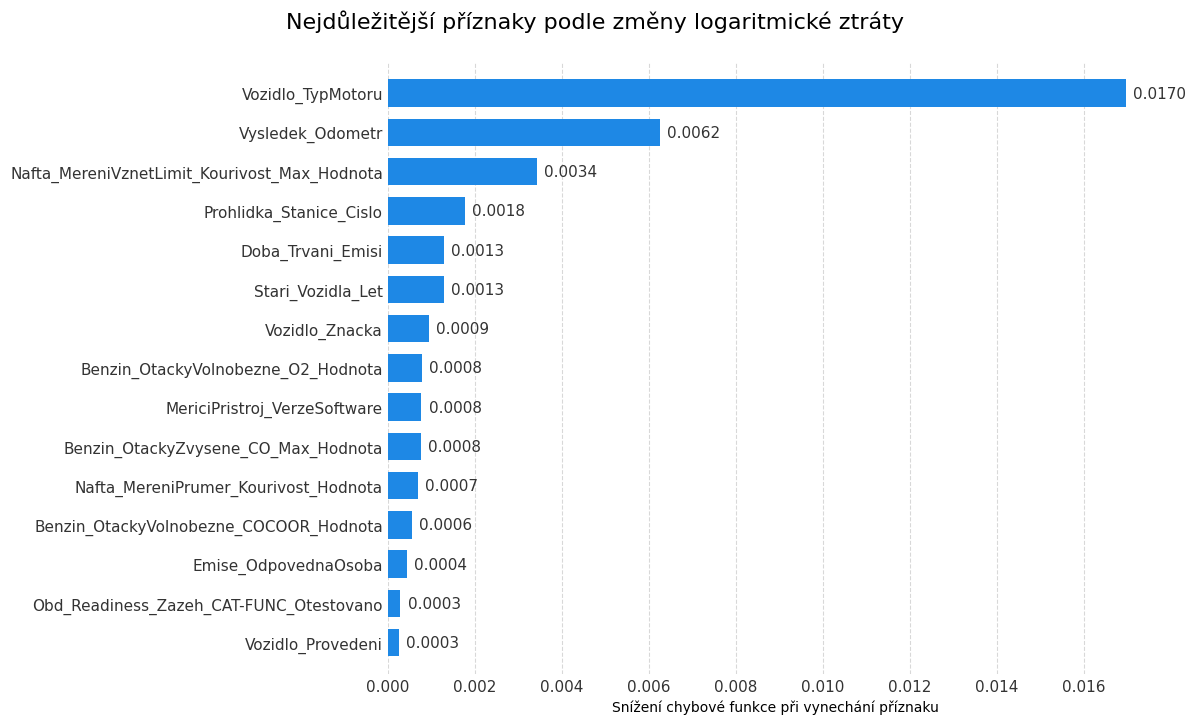

In [6]:
n_features = 15
horizontal_bar(
    labels=test_labels[:n_features],
    counts=test_values[:n_features],
    title='Nejdůležitější příznaky podle změny logaritmické ztráty',
    decimals=4,
    height=8,
    x_label='Snížení chybové funkce při vynechání příznaku',
    save_path='kod/modelovani/feature_importance.svg'
)